# Práctica 1: Aprendizaje automático
# Inteligencia Artificial
# Grado en Ingeniería Informática - Ingeniería del Software
# Universidad de Sevilla

[Scikit-learn](http://scikit-learn.org) es una biblioteca de aprendizaje automático de código abierto que implementa modelos de aprendizaje supervisado y no supervisado. También proporciona varias herramientas para el ajuste de modelos, el preprocesamiento de datos, la selección y evaluación de modelos y muchas otras utilidades.

Esta práctica presenta una introducción a esa biblioteca, mostrando cómo resolver una determinada tarea de aprendizaje supervisado mediante la construcción de modelos del tipo de los explicados en las clases teóricas de la asignatura.

## Predicción de situación de riesgo de sufrir un accidente cerebrovascular

Según la Organización Mundial de la Salud (OMS), el accidente cerebrovascular es la segunda causa de muerte a nivel mundial y es responsable de aproximadamente el 11 % del total de muertes.

 El fichero `stroke.csv` contiene un conjunto de datos de una serie de pacientes, indicando, para cada uno de ellos, si ha sufrido o no un accidente cerebrovascular y los valores de una serie de factores de riesgo como el sexo, la edad, diversas enfermedades y el tabaquismo.

In [ ]:
%pip install pandas --prefer-binary

  Using cached pandas-1.3.5.tar.gz (4.7 MB)
  Installing build dependencies ... |

In [ ]:
import pandas as pd

In [2]:
stroke = pd.read_csv('stroke.csv')
stroke.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,No,Yes,Yes,Private,Urban,228.69,36.6,formerly smoked,Yes
1,Male,80.0,No,Yes,Yes,Private,Rural,105.92,32.5,never smoked,Yes
2,Female,49.0,No,No,Yes,Private,Urban,171.23,34.4,smokes,Yes
3,Female,79.0,Yes,No,Yes,Self-employed,Rural,174.12,24.0,never smoked,Yes
4,Male,81.0,No,No,Yes,Private,Urban,186.21,29.0,formerly smoked,Yes


El objetivo es construir un modelo de aprendizaje automático que prediga, de la mejor manera posible, si un paciente está o no en riesgo de sufrir un accidente cerebrovascular a partir de los factores incluidos en el conjunto de datos:

- Sexo del paciente (`gender`): atributo discreto con posibles valores `Female` y `Male`.
- Edad del paciente (`age`): atributo continuo.
- ¿El paciente sufre de hipertensión? (`hypertension`): atributo discreto con posibles valores `No` y `Yes`.
- ¿El paciente está enfermo del corazón? (`heart_disease`): atributo discreto con posibles valores `No` y `Yes`.
- ¿El paciente está o ha estado casado? (`ever_married`): atributo discreto con posibles valores `No` y `Yes`.
- Tipo de trabajo del paciente (`work_type`): atributo discreto con posibles valores `children`, `Govt_jov`, `Never_worked`, `Private` y `Self-employed`.
- Tipo de domicilio del paciente (`Residence_type`): atributo discreto con posibles valores `Rural` y `Urban`.
- Nivel medio de glucosa en sangre del paciente (`avg_glucose_level`): atributo continuo.
- Índice de masa corporal del paciente (`bmi`): atributo continuo.
- Estado de tabaquismo del paciente (`smoking_status`): atributo discreto con posibles valores `formerly smoked`, `never smoked` y `smokes`.

El atributo objetivo es `stroke`, que es un atributo discreto con posibles valores `No` y `Yes` indicando si el paciente ha sufrido o no un accidente cerebrovascular. Se trata, por tanto, de realizar una **tarea de clasificación**.

A la hora de utilizar scikit-learn para abordar la tarea, hay que tener en cuenta las siguientes características generales de esa biblioteca:

- La biblioteca está organizada en módulos, siendo habitual importar únicamente las funciones y clases concretas que se vayan a usar, en lugar de importar toda la biblioteca o un módulo completo. Para ello se usarán expresiones de la forma `from sklearn.módulo import función_o_Clase`.
- La biblioteca está construida sobre Numpy por lo que, aunque mucha de la funcionalidad implementada admite recibir como entrada una Series o DataFrame de Pandas, los resultados se proporcionarán invariablemente en arrays de Numpy.
- Toda la funcionalidad relativa al aprendizaje supervisado espera recibir por separado un array bidimensional con los valores de los atributos que describen a los ejemplos y un array unidimensional con los valores del atributo objetivo.
- El esquema general de funcionamiento es crear una instancia de la clase que implemente la funcionalidad que se pretende aplicar y ejecutar el método `fit` para ajustar a los datos los parámetros de esa instancia.

Atendiendo a lo anterior, en primer lugar establecemos la semilla aleatoria inicial, para que el cuaderno sea reproducible a pesar de que posteriormente se llevarán a cabo operaciones aleatorias.

In [3]:
import numpy as np
np.random.seed(357823)

En segundo lugar, separamos los datos de los atributos de los ejemplos y los del atributo objetivo. A lo largo de la práctica también resultará de utilidad disponer por un lado de los nombres de los atributos discretos y por otro lado de los nombres de los atributos continuos.

In [10]:
atributos_discretos = ['gender', 'hypertension', 'heart_disease',
                       'ever_married', 'work_type', 'Residence_type',
                       'smoking_status']
atributos_continuos = ['age', 'avg_glucose_level', 'bmi']
atributos = stroke.loc[:, atributos_discretos + atributos_continuos]
atributos.head()  # atributos es un DataFrame bidimensional

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age,avg_glucose_level,bmi
0,Male,No,Yes,Yes,Private,Urban,formerly smoked,67.0,228.69,36.6
1,Male,No,Yes,Yes,Private,Rural,never smoked,80.0,105.92,32.5
2,Female,No,No,Yes,Private,Urban,smokes,49.0,171.23,34.4
3,Female,Yes,No,Yes,Self-employed,Rural,never smoked,79.0,174.12,24.0
4,Male,No,No,Yes,Private,Urban,formerly smoked,81.0,186.21,29.0


In [11]:
objetivo = stroke['stroke']
objetivo.head()  # objetivo es una Series unidimensional

0    Yes
1    Yes
2    Yes
3    Yes
4    Yes
Name: stroke, dtype: object

Scikit-learn únicamente trabaja con arrays numéricos, por lo que la primera labor a realizar es codificar numéricamente los atributos discretos y el atributo objetivo. Esta funcionalidad está incluida en el módulo `preprocessing` a partir de la clase `OrdinalEncoder`, que trabaja con arrays bidimensionales y está pensada para codificar los atributos, y de la clase `LabelEncoder`, que trabaja con arrays unidimensionales y está pensada para codificar el objetivo.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

Los pasos a seguir para realizar la codificación son los siguientes:

1. Crear una instancia de la clase correspondiente.
2. Usar el método `fit` para ajustar a los datos los parámetros de la codificación.
3. Aplicar el método `transform` para codificar los datos.

El método `fit_transform` realiza el paso 2, seguido del paso 3.

In [13]:
codificador_atributos_discretos = OrdinalEncoder()
codificador_atributos_discretos.fit(atributos[atributos_discretos])

,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,unknown_value,None
,encoded_missing_value,nan
,min_frequency,None
,max_categories,None


In [14]:
print('Número de atributos detectados:',
      f'{codificador_atributos_discretos.n_features_in_}')
print()
print('Nombres de los atributos detectados:')
print(f'{codificador_atributos_discretos.feature_names_in_}')
print()
print('Categorías detectadas de cada atributo:')
for atributo, categorías in zip(
    codificador_atributos_discretos.feature_names_in_,
    codificador_atributos_discretos.categories_):
    print(f'{atributo}: {categorías}')

Número de atributos detectados: 7

Nombres de los atributos detectados:
['gender' 'hypertension' 'heart_disease' 'ever_married' 'work_type'
 'Residence_type' 'smoking_status']

Categorías detectadas de cada atributo:
gender: ['Female' 'Male']
hypertension: ['No' 'Yes']
heart_disease: ['No' 'Yes']
ever_married: ['No' 'Yes']
work_type: ['Govt_job' 'Never_worked' 'Private' 'Self-employed' 'children']
Residence_type: ['Rural' 'Urban']
smoking_status: ['formerly smoked' 'never smoked' 'smokes']


In [15]:
# El método transform devuelve un array bidimensional con los datos codificados,
# que usamos para modificar el DataFrame de atributos y así mantener un
# DataFrame con los nombres de los atributos.
atributos[atributos_discretos] = codificador_atributos_discretos.transform(
    atributos[atributos_discretos]
)
atributos.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age,avg_glucose_level,bmi
0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,67.0,228.69,36.6
1,1.0,0.0,1.0,1.0,2.0,0.0,1.0,80.0,105.92,32.5
2,0.0,0.0,0.0,1.0,2.0,1.0,2.0,49.0,171.23,34.4
3,0.0,1.0,0.0,1.0,3.0,0.0,1.0,79.0,174.12,24.0
4,1.0,0.0,0.0,1.0,2.0,1.0,0.0,81.0,186.21,29.0


In [16]:
codificador_objetivo = LabelEncoder()
# El método fit_transform ajusta el codificador a los datos y, a continuación,
# codifica estos adecuadamente. En este caso no necesitamos mantener el
# atributo objetivo como una Series de Pandas.
objetivo = codificador_objetivo.fit_transform(objetivo)
print(f'Clases detectadas: {codificador_objetivo.classes_}')
objetivo

Clases detectadas: ['No' 'Yes']


array([1, 1, 1, ..., 0, 0, 0], shape=(3425,))

### Árbol de decisión

El primer tipo de modelo que vamos a construir es un árbol de decisión. Scikit-learn implementa los árboles CART en el módulo `tree`.

In [17]:
from sklearn.tree import DecisionTreeClassifier

En el caso de los modelos predictivos, el método `fit` ajusta a los datos los parámetros del modelo. En otras palabras, entrena el modelo a partir de los valores de los atributos para cada ejemplo y de los valores del atributo objetivo para cada ejemplo.

In [18]:
# Scikit-learn implementa el algoritmo CART de tal manera que, al buscar en
# cada nodo la mejor combinación atributo-umbral para particionar el conjunto
# de ejemplos asociado al nodo, no considera los atributos en orden, sino que
# los reordena aleatoriamente. Esto puede hacer que se obtenga un árbol
# distinto cada vez que se ejecuta el código, ya que produce como efecto que
# los empates en esa búsqueda se deshacen de forma aleatoria. Por tanto, para
# que el código sea reproducible debemos establecer una semilla aleatoria inicial.

# Por otra parte, para evitar el sobreajuste del árbol a los ejemplos de
# entrenamiento vamos a limitar la profundidad del árbol construido.

clasificador_CART = DecisionTreeClassifier(
    max_depth=4
)
clasificador_CART.fit(atributos, objetivo)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


La función `plot_tree` del módulo `tree` construye representaciones gráficas de los árboles apoyándose en el paquete `matplotlib`.

In [19]:
from matplotlib import pyplot
from sklearn.tree import plot_tree

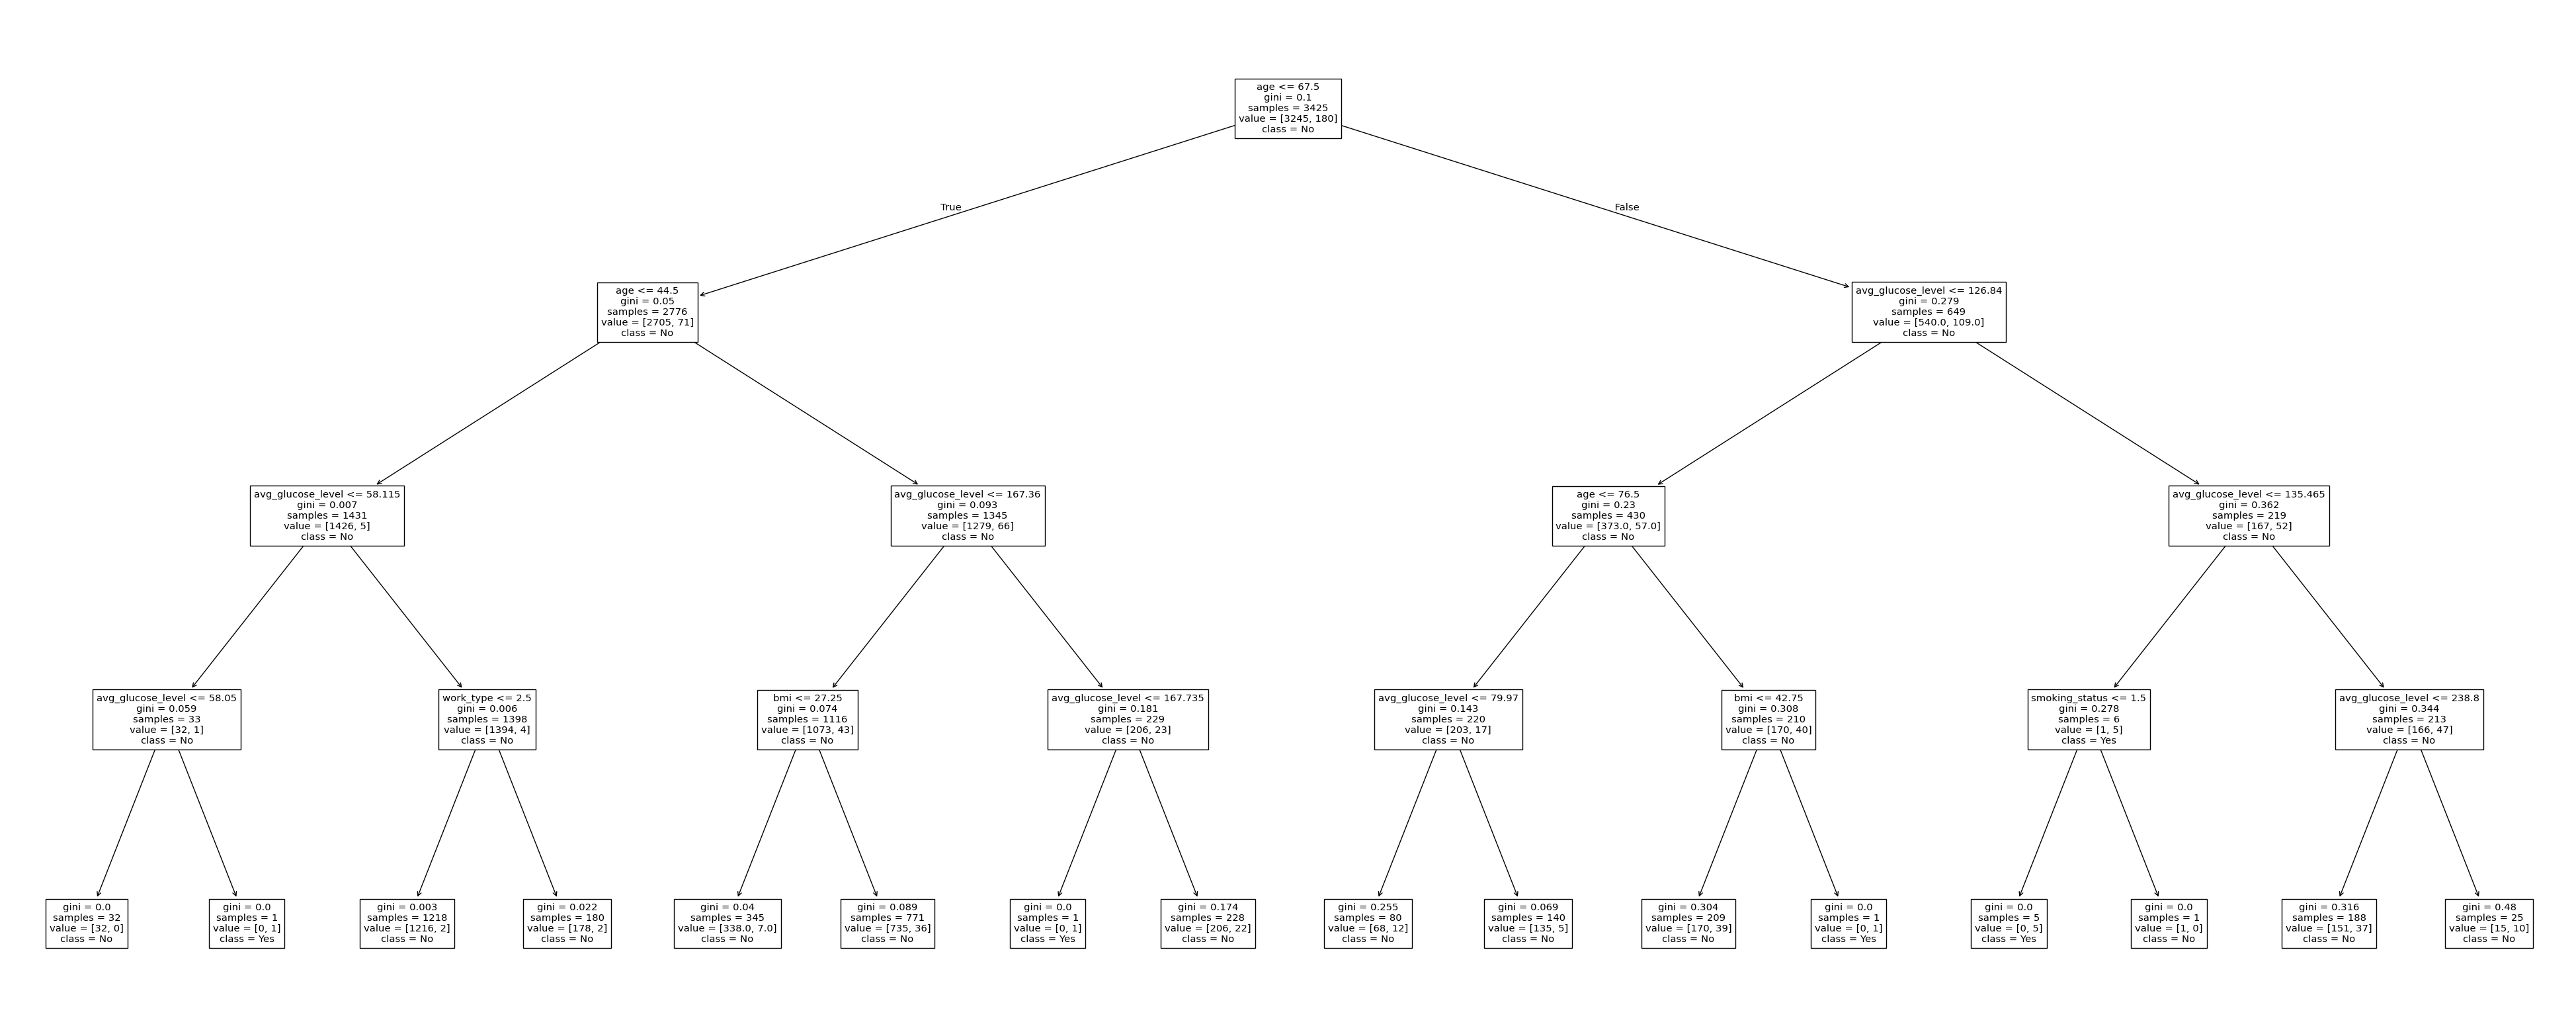

In [20]:
pyplot.figure(figsize=(50, 20))  # Anchura y altura del gráfico
árbol = plot_tree(clasificador_CART,
                  # El argumento feature_names permite proporcionar, en una
                  # lista, los nombres de los atributos.
                  feature_names=atributos_discretos + atributos_continuos,
                  # El argumento class_names permite proporcionar, en una
                  # lista, los nombres de las clases
                  class_names=['No', 'Yes'])

Ahora, en lugar de usar el método `transform` de los preprocesadores, se usa el método `predict` para obtener las predicciones del modelo para cada ejemplo y el método `score` para obtener la tasa de acierto.

In [21]:
predicciones = clasificador_CART.predict(atributos)
predicciones

array([0, 0, 0, ..., 0, 0, 0], shape=(3425,))

In [22]:
clasificador_CART.score(atributos, objetivo)

0.9497810218978102

El modelo ha obtenido una tasa de acierto de casi un 95&nbsp;%, pero eso no quiere decir que sea un buen modelo. En efecto, el atributo objetivo está muy desequilibrado hacia la clase negativa, por lo que al modelo le basta con predecir esa clase casi siempre para tener una alta tasa de acierto.

In [23]:
pd.Series(objetivo).value_counts()

0    3245
1     180
Name: count, dtype: int64

In [82]:
pd.Series(predicciones).value_counts()

0    3409
1      16
Name: count, dtype: int64

Pero esto quiere decir que el modelo producirá muchos falsos negativos, tal y como muestra la matriz de confusión.

In [81]:
from sklearn.metrics import confusion_matrix

In [26]:
confusion_matrix(objetivo, predicciones)

array([[3245,    0],
       [ 172,    8]])

Si lo importante es detectar aquellos pacientes susceptibles de sufrir un accidente cerebrovascular, aún a costa de que se puedan producir falsos positivos, entonces es mejor evaluar el rendimiento del modelo mediante la sensibilidad.

In [27]:
from sklearn.metrics import recall_score

In [28]:
recall_score(objetivo, predicciones)

0.044444444444444446

La sensibilidad del árbol de decisión es, en este caso, muy baja.

### Naive Bayes

Para poder construir un modelo naive Bayes se requiere que todos los atributos sean discretos, por lo que es necesario discretizar previamente los atributos continuos. Scikit-learn proporciona para ello el preprocesador `KBinsDiscretizer`.

In [29]:
from sklearn.preprocessing import KBinsDiscretizer

In [30]:
discretizador = KBinsDiscretizer(
    n_bins=4,  # Cada atributo se discretiza en 4 intervalos
    encode='ordinal',  # Los intervalos se codifican numéricamente
    strategy='quantile'  # Cada intervalo contiene la misma cantidad de datos
)

# Como nos interesa conservar los atributos continuos originales, realizamos
# la discretización sobre una copia del DataFrame de atributos
atributos_discretizados = atributos.copy()
atributos_discretizados[atributos_continuos] = discretizador.fit_transform(
    atributos_discretizados[atributos_continuos]
)
atributos_discretizados.head()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age,avg_glucose_level,bmi
0,1.0,0.0,1.0,1.0,2.0,1.0,0.0,3.0,3.0,3.0
1,1.0,0.0,1.0,1.0,2.0,0.0,1.0,3.0,2.0,2.0
2,0.0,0.0,0.0,1.0,2.0,1.0,2.0,1.0,3.0,3.0
3,0.0,1.0,0.0,1.0,3.0,0.0,1.0,3.0,3.0,0.0
4,1.0,0.0,0.0,1.0,2.0,1.0,0.0,3.0,3.0,1.0


Scikit-learn implementa los modelos de tipo naive Bayes en el módulo `naive_bayes`. El tipo de modelo explicado en las clases teóricas está implementado en la clase `CategoricalNB`.

In [31]:
from sklearn.naive_bayes import CategoricalNB

In [32]:
clasificador_NB = CategoricalNB(alpha=1)  # alpha es el parámetro de suavizado
clasificador_NB.fit(atributos_discretizados, objetivo)

,alpha,1
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


Podemos comprobar cómo se han estimado los parámetros del modelo mediante una estimación de máxima verosimilitud usando suavizado de Laplace.

In [33]:
for clase, cantidad_ejemplos_clase, log_probabilidad_clase in zip(
    clasificador_NB.classes_,
    clasificador_NB.class_count_,
    clasificador_NB.class_log_prior_
):
        print(f'Cantidad de ejemplos para la clase {clase}: {cantidad_ejemplos_clase}')
        print(f'Logaritmo de la probabilidad aprendida para la clase {clase}: {log_probabilidad_clase}')

Cantidad de ejemplos para la clase 0: 3245.0
Logaritmo de la probabilidad aprendida para la clase 0: -0.053986121558134315
Cantidad de ejemplos para la clase 1: 180.0
Logaritmo de la probabilidad aprendida para la clase 1: -2.9458998998061148


In [34]:
for i, atributo in enumerate(clasificador_NB.feature_names_in_):
    print(f'Cantidad de ejemplos para el atributo {atributo}:')
    print(pd.DataFrame(clasificador_NB.category_count_[i],
                       columns=range(clasificador_NB.n_categories_[i]),
                       index=clasificador_NB.classes_))
    print(f'Logaritmos de las probabilidades aprendidas para el atributo {atributo}:')
    print(pd.DataFrame(clasificador_NB.feature_log_prob_[i],
                       columns=range(clasificador_NB.n_categories_[i]),
                       index=clasificador_NB.classes_))
    print()

Cantidad de ejemplos para el atributo gender:
        0       1
0  1981.0  1264.0
1   105.0    75.0
Logaritmos de las probabilidades aprendidas para el atributo gender:
          0         1
0 -0.493625 -0.942659
1 -0.540568 -0.873273

Cantidad de ejemplos para el atributo hypertension:
        0      1
0  2894.0  351.0
1   123.0   57.0
Logaritmos de las probabilidades aprendidas para el atributo hypertension:
          0         1
0 -0.114746 -2.221856
1 -0.383725 -1.143564

Cantidad de ejemplos para el atributo heart_disease:
        0      1
0  3075.0  170.0
1   144.0   36.0
Logaritmos de las probabilidades aprendidas para el atributo heart_disease:
          0         1
0 -0.054101 -2.943823
1 -0.227273 -1.593089

Cantidad de ejemplos para el atributo ever_married:
       0       1
0  806.0  2439.0
1   20.0   160.0
Logaritmos de las probabilidades aprendidas para el atributo ever_married:
          0         1
0 -1.392163 -0.285733
1 -2.159484 -0.122602

Cantidad de ejemplos para e

Para este modelo se obtiene una mayor sensibilidad que para el árbol de decisión.

In [35]:
predicciones = clasificador_NB.predict(atributos_discretizados)
predicciones

array([1, 0, 0, ..., 0, 0, 0], shape=(3425,))

In [36]:
confusion_matrix(objetivo, predicciones)

array([[3155,   90],
       [ 154,   26]])

In [37]:
recall_score(objetivo, predicciones)

0.14444444444444443

### $k$NN

Puesto que algunos de los atributos que describen los ejemplos son continuos, una métrica adecuada a la hora de construir un modelo $k$NN es la distancia euclídea (en https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html se listan los nombres de distintas distancias que se pueden utilizar). Es entonces conveniente normalizar previamente todos los atributos, para que ninguno de ellos domine sobre los demás. Scikit-learn proporciona para ello distintos preprocesadores, como por ejemplo el implementado en la clase `MinMaxScaler`, que permite transformar los valores a un intervalo determinado.

In [38]:
from sklearn.preprocessing import MinMaxScaler

In [39]:
normalizador = MinMaxScaler(
    # Cada atributo se normaliza al intervalo [0, 1]
    feature_range=(0, 1)
)

# Como nos interesa conservar los atributos originales, realizamos la
# normalización sobre una copia del DataFrame de atributos
atributos_normalizados = atributos.copy()
atributos_normalizados[:] = normalizador.fit_transform(atributos_normalizados)
atributos_normalizados.head()

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age,avg_glucose_level,bmi
0,1.0,0.0,1.0,1.0,0.50,1.0,0.0,0.791667,0.801265,0.311801
1,1.0,0.0,1.0,1.0,0.50,0.0,0.5,0.972222,0.234512,0.260870
2,0.0,0.0,0.0,1.0,0.50,1.0,1.0,0.541667,0.536008,0.284472
3,0.0,1.0,0.0,1.0,0.75,0.0,0.5,0.958333,0.549349,0.155280
4,1.0,0.0,0.0,1.0,0.50,1.0,0.0,0.986111,0.605161,0.217391


Scikit-learn implementa los modelos de tipo vecinos más cercanos en el módulo `neighbors`. El tipo de modelo explicado en las clases teóricas está implementado en la clase `KNeighborsClassifier`.

In [40]:
from sklearn.neighbors import KNeighborsClassifier

In [41]:
clasificador_kNN = KNeighborsClassifier(
    # Para cada ejemplo se consideran los 5 ejemplos más cercanos
    n_neighbors=5,
    # La cercanía viene determinada por la distancia euclídea
    metric='euclidean'
)
clasificador_kNN.fit(atributos_normalizados, objetivo)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


Para este modelo se obtiene una mayor sensibilidad que para el árbol de decisión, pero una menor sensibilidad que para naive Bayes.

In [42]:
predicciones = clasificador_kNN.predict(atributos_normalizados)
predicciones

array([0, 0, 0, ..., 0, 0, 0], shape=(3425,))

In [43]:
confusion_matrix(objetivo, predicciones)

array([[3238,    7],
       [ 171,    9]])

In [44]:
recall_score(objetivo, predicciones)

0.05

## Evaluación y selección de modelos

Anteriormente se ha explicado cómo usar la biblioteca scikit-learn para el preprocesamiento de datos y la construcción de modelos de árboles de decisión, naive Bayes y $k$NN. Sin embargo, la evaluación de los modelos construidos no se ha llevado a cabo correctamente, ya que se ha realizado sobre los propios ejemplos de entrenamiento. En lo que sigue se va a explicar cómo usar scikit-learn para aplicar las distintas técnicas de evaluación y selección de modelos explicadas en las clases de teoría.

En primer lugar, usamos la función `train_test_split` del módulo `model_selection` para dividir el conjunto de ejemplos en un subconjunto de entrenamiento y un subconjunto de prueba. Este último se retendrá hasta que se seleccione un modelo final, usándose entonces para determinar el rendimiento de ese modelo con ejemplos totalmente nuevos. En general, al abordar una tarea de clasificación y aplicar el método de validación por retención, es importante mantener en cada uno de los subconjuntos aproximadamente la misma proporción de ejemplos de cada clase que había en el conjunto inicial.

In [45]:
from sklearn.model_selection import train_test_split

In [46]:
(atributos_entrenamiento, atributos_prueba,
 objetivo_entrenamiento, objetivo_prueba) = train_test_split(
        # Conjuntos de datos a dividir, usando los mismos índices para ambos
        atributos, objetivo,
        # Tamaño del conjunto de prueba (20 % en este caso)
        test_size=.2,
        # Estratificación según la distribución de clases en el atributo objetivo
        stratify=objetivo)

Podemos comprobar que para el entrenamiento se han obtenido subconjuntos con un 80&nbsp;% de los ejemplos y para la prueba subconjuntos con un 20&nbsp;% de los ejemplos.

In [47]:
print(f'Cantidad inicial de ejemplos: {objetivo.size}',
      f'(80 % = {objetivo.size * .8}, 20 % = {objetivo.size * .2})')
print('Atributos:',
      f'Entrenamiento ({atributos_entrenamiento.shape[0]} ejemplos)',
      f'Prueba ({atributos_prueba.shape[0]} ejemplos)')
print('Objetivo:',
      f'Entrenamiento ({objetivo_entrenamiento.shape[0]} ejemplos)',
      f'Prueba ({objetivo_prueba.shape[0]} ejemplos)')

Cantidad inicial de ejemplos: 3425 (80 % = 2740.0, 20 % = 685.0)
Atributos: Entrenamiento (2740 ejemplos) Prueba (685 ejemplos)
Objetivo: Entrenamiento (2740 ejemplos) Prueba (685 ejemplos)


También podemos comprobar que se mantiene la proporción de ejemplos en cada clase tanto para el subconjunto de entrenamiento como para el de prueba.

In [48]:
print('Proporción inicial de ejemplos:')
print(pd.Series(objetivo).value_counts(normalize=True))
print('Proporción de ejemplos de entrenamiento:')
print(pd.Series(objetivo_entrenamiento).value_counts(normalize=True))
print('Proporción de ejemplos de prueba:')
print(pd.Series(objetivo_prueba).value_counts(normalize=True))

Proporción inicial de ejemplos:
0    0.947445
1    0.052555
Name: proportion, dtype: float64
Proporción de ejemplos de entrenamiento:
0    0.947445
1    0.052555
Name: proportion, dtype: float64
Proporción de ejemplos de prueba:
0    0.947445
1    0.052555
Name: proportion, dtype: float64


Ahora procedemos a estimar el rendimiento de los modelos a partir del subconjunto de entrenamiento, usando para ello el método de validación cruzada. La función `cross_validate` del módulo `model_selection` implementa este método de validación.

In [49]:
from sklearn.model_selection import cross_validate

Para estimar el rendimiento de un modelo de aprendizaje supervisado habría que realizar los siguientes pasos:

1. Crear una instancia del modelo, pero no ajustarlo a los datos.
2. Pasar esa instancia a la función `cross_validate`, junto con los ejemplos de entrenamiento (valores de los atributos y del atributo objetivo por separado), la medida de rendimiento a utilizar y la cantidad de pliegues a considerar.

Por ejemplo, a continuación estimamos mediante validación cruzada la sensibilidad de un árbol de decisión construido hasta una profundidad máxima 4 y requiriendo al menos 5 ejemplos para particionar cada subconjunto.

In [50]:
clasificador_CART = DecisionTreeClassifier(
    max_depth=4,  # Máxima profundidad del árbol
    min_samples_split=5  # Mínimo número de ejemplos para poder particionar
)

In [51]:
resultados_validación_cruzada = cross_validate(clasificador_CART,
                                               atributos_entrenamiento,
                                               objetivo_entrenamiento,
                                               scoring='recall',
                                               cv=10)
resultados_validación_cruzada

{'fit_time': array([0.00432968, 0.00374246, 0.00423503, 0.00363517, 0.00381875,
        0.00361109, 0.00342846, 0.00329924, 0.00344706, 0.00387716]),
 'score_time': array([0.00235891, 0.00237346, 0.00218987, 0.00235558, 0.00244474,
        0.00249147, 0.00210071, 0.0020299 , 0.00244522, 0.00199628]),
 'test_score': array([0.        , 0.        , 0.07142857, 0.        , 0.        ,
        0.        , 0.06666667, 0.        , 0.        , 0.        ])}

El rendimiento del modelo en cada pliegue se proporciona en la componente `test_score` de los resultados, siendo habitual proporcionar la media de los mismos como estimación final del rendimiento del modelo.

In [52]:
resultados_validación_cruzada['test_score'].mean()

np.float64(0.01380952380952381)

El procedimiento de selección de modelos consiste en estimar el rendimiento de distintos modelos, ya sean de distinto tipo o del mismo tipo, pero entrenados con distintos valores de los hiperparámetros, y seleccionar el modelo más adecuado a partir de los resultados obtenidos. Evidentemente, es conveniente realizar esa búsqueda del mejor modelo de una manera automatizada y sistemática.

La clase `GridSearchCV` del módulo `model_selection` implementa una búsqueda en rejilla en la que se aplica el método de validación cruzada para cada combinación de los valores especificados de los hiperparámetros. Los pasos a seguir son los siguientes:

1. Crear una instancia del modelo sin establecer los valores de los hiperparámetros de interés.
2. Crear un diccionario con la lista de valores a considerar para cada hiperparámetro.
3. Crear una instancia de `GridSearchCV` proporcionándole el modelo, la rejilla de hiperparámetros, la medida de rendimiento a utilizar y la cantidad de pliegues a considerar.
4. Ajustar la búsqueda al conjunto de entrenamiento.

In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
clasificador_CART = DecisionTreeClassifier()
rejilla_de_hiperparámetros = {
    # Máxima profundidad del árbol: 3, 4, 5, 6, 7, 8, 9, 10
    'max_depth': range(3, 11),
    # Mínimo número de ejemplos para poder particionar: 5, 10, 15
    'min_samples_split': range(5, 20, 5)
}

In [55]:
búsqueda_en_rejilla = GridSearchCV(clasificador_CART,
                                   rejilla_de_hiperparámetros,
                                   scoring='recall',
                                   cv=10)
búsqueda_en_rejilla.fit(atributos_entrenamiento, objetivo_entrenamiento)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': range(3, 11), 'min_samples_split': range(5, 20, 5)}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


Los resultados de la búsqueda se guardan en el atributo `cv_results_`, mientras que los mejores valores de los hiperparámetros y el mejor rendimiento correspondiente se encuentran en los atributos `best_params_` y `best_score_`.

In [56]:
búsqueda_en_rejilla.cv_results_

{'mean_fit_time': array([0.0032629 , 0.00323687, 0.00311656, 0.00353818, 0.00358508,
        0.00347924, 0.00421441, 0.00394399, 0.00405471, 0.00443387,
        0.00451379, 0.00475698, 0.00504599, 0.00473781, 0.00477221,
        0.00511022, 0.0052233 , 0.0080394 , 0.00621045, 0.00482352,
        0.00455985, 0.0049854 , 0.00478842, 0.00474215]),
 'std_fit_time': array([0.0003808 , 0.00026003, 0.00019047, 0.00018779, 0.00027916,
        0.00028747, 0.00031673, 0.00022634, 0.00026073, 0.00041871,
        0.00020007, 0.00029286, 0.00060491, 0.00026052, 0.0003788 ,
        0.00017211, 0.00040258, 0.00532971, 0.00120225, 0.0001644 ,
        0.00011737, 0.00032918, 0.00022121, 0.00010893]),
 'mean_score_time': array([0.00211592, 0.00219061, 0.00206439, 0.0021625 , 0.0021184 ,
        0.00208147, 0.00227742, 0.00215955, 0.00211015, 0.00226018,
        0.00234299, 0.00251057, 0.00235832, 0.00222988, 0.00231774,
        0.00231576, 0.00250881, 0.00540228, 0.00268593, 0.0019176 ,
        0.001811

In [57]:
búsqueda_en_rejilla.best_params_

{'max_depth': 10, 'min_samples_split': 5}

In [58]:
búsqueda_en_rejilla.best_score_

np.float64(0.09761904761904762)

A la hora de realizar una búsqueda en rejilla para buscar los mejores modelos naive Bayes y $k$NN posibles debemos tener cuidado de que no se produzca lo que se conoce como fuga de datos (_data leakage_, en inglés). Es decir, no podemos usar información del conjunto de prueba para entrenar el modelo. Esto se traduce en que preprocesar el conjunto entero de datos y luego aplicar validación cruzada no es correcto, ya que al considerar cada pliegue, sus ejemplos no deben tenerse en cuenta al preprocesar los datos del resto de pliegues. En otras palabras, el preprocesado de los datos debe integrarse dentro del procedimiento de validación cruzada.

Scikit-learn facilita establecer esa integración mediante el uso de los transformadores de columnas y de las tuberías.

Una instancia de la clase `ColumnTransformer` del módulo `compose` permite establecer un conjunto de transformaciones a realizar sobre las columnas de un conjunto de datos. Ese conjunto de transformaciones debe proporcionarse como una lista de tuplas de la forma `(nombre, transformador, columns)`, donde:

- `nombre` es una cadena.
- `transformador` es una instancia de una clase que implemente los métodos `fit` y `transform`. También puede ser la cadena `'drop'` para descartar las columnas o la cadena `'passthrough'` para mantenerlas sin transformar.
- `columns` es la columna o lista de columnas a transformar.

El argumento `remainder` permite indicar la transformación a realizar sobre el resto de columnas no especificadas en la secuencia de transformaciones.

In [59]:
from sklearn.compose import ColumnTransformer

Vamos a crear a continuación un transformador de columnas para discretizar los atributos continuos del conjunto de datos.

In [60]:
discretizador = ColumnTransformer(
    [
        # Establecemos una única transformación a realizar, de nombre discretizador
        ('discretizador',
         # La transformación consiste en discretizar el atributo en 4 intervalos
         # con la misma cantidad de datos en cada uno de ellos y codificados con
         # números enteros
         KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile'),
         # Indicamos por su nombre los atributos a discretizar
         atributos_continuos)
    ],
    # Mantenemos el resto de atributos sin transformar
    remainder='passthrough'
)

Ahora podemos discretizar los atributos continuos para cualquier subconjunto de ejemplos.

In [61]:
discretizador.fit(
    atributos  # Todos los ejemplos
)
# Extremos de los intervalos aprendidos
discretizador.named_transformers_['discretizador'].bin_edges_

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([array([10., 34., 50., 63., 82.]),
       array([ 55.12,  77.23,  92.35, 116.2 , 271.74]),
       array([11.5, 25.3, 29.1, 34.1, 92. ])], dtype=object)

In [62]:
discretizador.fit(
    atributos[atributos['gender'] == 0.0]  # Solo los ejemplos de sexo Female
)
discretizador.named_transformers_['discretizador'].bin_edges_

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([array([10.  , 33.  , 48.  , 62.75, 82.  ]),
       array([ 55.12 ,  76.31 ,  91.005, 112.975, 267.76 ]),
       array([14.1  , 24.6  , 28.7  , 34.375, 78.   ])], dtype=object)

In [63]:
discretizador.fit(
    atributos[atributos['gender'] == 1.0]  # Solo los ejemplos de sexo Male
)
discretizador.named_transformers_['discretizador'].bin_edges_

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


array([array([10. , 35.5, 52. , 64. , 82. ]),
       array([ 55.22 ,  78.505,  94.65 , 122.605, 271.74 ]),
       array([11.5, 26.3, 29.5, 33.6, 92. ])], dtype=object)

Una instancia de la clase `Pipeline` del módulo `pipeline` permite concatenar una secuencia de operaciones de preprocesamiento de datos finalizando con el entrenamiento de un modelo. Esa secuencia de operaciones debe proporcionarse como una secuencia de tuplas `(nombre, estimador)`, donde:

- `nombre` es una cadena.
- `estimador` es un transformador que debe implementar los métodos `fit` y `transform`, salvo el último que es un estimador al que solo se le exige la implementación del método `fit`.

In [78]:
from sklearn.pipeline import Pipeline

Vamos a crear a continuación una tubería que primero discretice los atributos continuos y luego entrene un modelo naive Bayes con suavizado de Laplace.

In [79]:
tubería_NB = Pipeline([('preprocesador', discretizador),
                       ('naive_Bayes', CategoricalNB(alpha=1))])

Ahora podemos realizar un procedimiento de validación cruzada sin incurrir en fuga de datos.

In [80]:
resultados_validación_cruzada = cross_validate(tubería_NB,
                                               atributos_entrenamiento,
                                               objetivo_entrenamiento,
                                               scoring='recall',
                                               cv=10)
resultados_validación_cruzada

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be ch

{'fit_time': array([0.00742197, 0.00577879, 0.00522923, 0.00589514, 0.00688076,
        0.00781083, 0.00943351, 0.0069778 , 0.00603342, 0.00631428]),
 'score_time': array([0.00355983, 0.00336432, 0.00312662, 0.00376654, 0.00458622,
        0.0051775 , 0.00474381, 0.00348568, 0.00353956, 0.00443125]),
 'test_score': array([0.        , 0.14285714, 0.14285714, 0.14285714, 0.14285714,
        0.21428571, 0.06666667, 0.13333333, 0.13333333, 0.33333333])}

In [67]:
resultados_validación_cruzada['test_score'].mean()

np.float64(0.14523809523809522)

Para poder realizar una búsqueda en rejilla hay que usar el esquema `nombre-del-estimador__nombre-del-hiperparámetro` al establecer la rejilla de hiperparámetros.

In [68]:
tubería_NB = Pipeline([('preprocesador', discretizador),
                       ('naive_Bayes', CategoricalNB())])
rejilla_de_hiperparámetros = {
    # Suavizado del estimador llamado naive_Bayes
    'naive_Bayes__alpha': range(1, 11)
}

In [69]:
búsqueda_en_rejilla = GridSearchCV(tubería_NB,
                                   rejilla_de_hiperparámetros,
                                   scoring='recall',
                                   cv=10)
búsqueda_en_rejilla.fit(atributos_entrenamiento, objetivo_entrenamiento)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be ch

,estimator,Pipeline(step...goricalNB())])
,param_grid,"{'naive_Bayes__alpha': range(1, 11)}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('discretizador', ...)]"


In [70]:
búsqueda_en_rejilla.best_params_

{'naive_Bayes__alpha': 1}

In [71]:
búsqueda_en_rejilla.best_score_

np.float64(0.14523809523809522)

Para el modelo $k$NN hay que construir una tubería que primero normalice los atributos y después entrene el modelo.

In [72]:
normalizador = ColumnTransformer([('normalizador',
                                   MinMaxScaler(feature_range=(0, 1)),
                                   atributos_discretos + atributos_continuos)])

In [73]:
tubería_kNN = Pipeline([('preprocesador', normalizador),
                        ('kNN', KNeighborsClassifier())])
rejilla_de_parámetros = {
    # Número de vecinos impar (tarea de clasificación binaria)
    'kNN__n_neighbors': range(1, 10, 2),
    # Considerar las distancias Manhattan y euclídea
    'kNN__metric': ['manhattan', 'euclidean']
}

In [74]:
búsqueda_en_rejilla = GridSearchCV(tubería_kNN,
                                   rejilla_de_parámetros,
                                   scoring='recall',
                                   cv=10)
búsqueda_en_rejilla.fit(atributos_entrenamiento, objetivo_entrenamiento)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'kNN__metric': ['manhattan', 'euclidean'], 'kNN__n_neighbors': range(1, 10, 2)}"
,scoring,'recall'
,n_jobs,None
,refit,True
,cv,10
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('normalizador', ...)]"


In [75]:
búsqueda_en_rejilla.best_params_

{'kNN__metric': 'euclidean', 'kNN__n_neighbors': 1}

In [76]:
búsqueda_en_rejilla.best_score_

np.float64(0.0980952380952381)

El modelo que hemos encontrado que tiene mayor sensibilidad es el modelo naive Bayes con suavizado de Laplace entrenado tras discretizar los atributos continuos en 4 intervalos con la misma cantidad de valores cada uno.

El paso final es entrenar ese modelo con el conjunto de entrenamiento completo y proporcionar como rendimiento final del modelo su sensibilidad sobre el conjunto de prueba que teníamos reservado.

In [77]:
modelo_seleccionado = Pipeline(
    [('preprocesador',
      ColumnTransformer([('discretizador',
                          KBinsDiscretizer(n_bins=4,
                                           encode='ordinal',
                                           strategy='quantile'),
                          atributos_continuos)],
                        remainder='passthrough')),
     ('modelo',
      CategoricalNB(alpha=1))]
)
modelo_seleccionado.fit(atributos_entrenamiento, objetivo_entrenamiento)
predicciones_prueba = modelo_seleccionado.predict(atributos_prueba)
recall_score(objetivo_prueba, predicciones_prueba)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_discretization.py:296: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


0.1111111111111111